In [2]:
import pandas as pd
df=pd.read_csv("employees(1).csv")
df.head()

,First Name,Gender,Start Date,Last Login Time,Salary,Bonus %,Senior Management,Team
0,Douglas,Male,8/6/1993,12:42 PM,97308,6.945,True,Marketing
1,Thomas,Male,3/31/1996,6:53 AM,61933,4.170,True,NaN
2,Maria,Female,4/23/1993,11:17 AM,130590,11.858,False,Finance
3,Jerry,Male,3/4/2005,1:00 PM,138705,9.340,True,Finance
4,Larry,Male,1/24/1998,4:47 PM,101004,1.389,True,Client Services


In [5]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df=pd.read_csv("cleaned_employees.csv")
df["Start Date"]=pd.to_datetime(
    df["Start Date"],errors="coerce"
)
df.head()

,First Name,Gender,Start Date,Last Login Time,Salary,Bonus %,Senior Management,Team
0,Douglas,Male,1993-08-06,12:42 PM,97308.0,6.945,True,Marketing
1,Thomas,Male,1996-03-31,6:53 AM,61933.0,4.170,True,Client Services
2,Maria,Female,1993-04-23,11:17 AM,130590.0,11.858,False,Finance
3,Jerry,Male,2005-03-04,1:00 PM,138705.0,9.340,True,Finance
4,Larry,Male,1998-01-24,4:47 PM,101004.0,1.389,True,Client Services


In [7]:
#Salary statistics 
df["Salary"].describe()
###Salary analysis 
##the salary statistics an overview of employee compensation.the mean and median salary help understand the typical salary level,while minimum and maximum values show the overall salary range.

count      1000.000000
mean      90662.181000
std       32923.693342
min       35013.000000
25%       62613.000000
50%       90428.000000
75%      118740.250000
max      149908.000000
Name: Salary, dtype: float64

In [8]:
team_salary=df.groupby("Team")["Salary"].agg(["count","mean","median","min","max"]
                                             ).sort_values("mean",ascending=False)
team_salary


,count,mean,median,min,max
Team,,,,,
Engineering,92,94269.195652,95273.0,36946.0,147362.0
Finance,102,92219.480392,88873.5,35381.0,149908.0
Sales,94,92173.436170,91238.5,35802.0,149654.0
Business Development,101,91866.316832,93997.0,36844.0,147417.0
Human Resources,91,90944.527473,93022.0,35203.0,149903.0
Marketing,98,90435.591837,85381.5,36643.0,149456.0
Legal,88,89303.613636,87994.5,35061.0,148985.0
Client Services,149,88957.073826,87103.0,35095.0,148291.0
Product,95,88665.505263,88657.0,35013.0,149684.0


##team analysis
this analysis compares salary levels across different teams. it help identify team with higher average compensation and differences in salary distribution.

In [9]:
gender_salary=df.groupby("Gender")["Salary"].agg(["count","mean","median"])
gender_salary

,count,mean,median
Gender,,,
Female,576,90280.515625,90569.0
Male,424,91180.669811,90112.0


##this analysis compares employee salary statistics across gender categories.
this comparison include employee count,average salary, and median salary.

In [10]:
management_salary=df.groupby(
    "Senior Management")["Salary"].agg(["count","mean","median"])
management_salary

,count,mean,median
Senior Management,,,
False,465,89638.264516,88657.0
True,535,91552.127103,91344.0


this shows the salary difference between employees with and without senior management roles.

In [11]:
bonus_by_team=(df.groupby("Team")["Bonus %"].mean().sort_values(ascending=False))
bonus_by_team

Team
Business Development    10.572376
Client Services         10.463154
Engineering             10.462989
Marketing               10.353449
Legal                   10.322830
Finance                 10.186873
Sales                   10.116915
Human Resources          9.993879
Product                  9.791484
Distribution             9.615644
Name: Bonus %, dtype: float64

this analysis identifies team with higher average bonus percentages and helps compare compensation incentives across teams.

In [12]:
df["Start Year"]=df["Start Date"].dt.year
hiring_year=(df["Start Year"].value_counts().sort_index())
hiring_year

Start Year
1980    30
1981    21
1982    28
1983    22
1984    32
1985    18
1986    28
1987    16
1988    25
1989    20
1990    22
1991    27
1992    28
1993    19
1994    24
1995    44
1996    32
1997    29
1998    19
1999    37
2000    26
2001    25
2002    34
2003    26
2004    31
2005    31
2006    26
2007    33
2008    25
2009    42
2010    28
2011    30
2012    28
2013    29
2014    28
2015    22
2016    15
Name: count, dtype: int64

this analysis shows the number of employees who joined the organization in each year and helps identify hiring trends over time.

In [13]:
numeric_columns=df.select_dtypes(
    include=np.number
)
numeric_columns.head()

,Salary,Bonus %,Start Year
0,97308.0,6.945,1993
1,61933.0,4.170,1996
2,130590.0,11.858,1993
3,138705.0,9.340,2005
4,101004.0,1.389,1998


this selects all columns that contain numerical values and displays the first 5 rows

In [14]:
correlation=numeric_columns.corr()
print(correlation)

              Salary   Bonus %  Start Year
Salary      1.000000 -0.036381    0.033089
Bonus %    -0.036381  1.000000   -0.047887
Start Year  0.033089 -0.047887    1.000000


this analysis show to how much two numerical columns are relationship..like +1 strong 0 no linear relationship -1 strong negative 

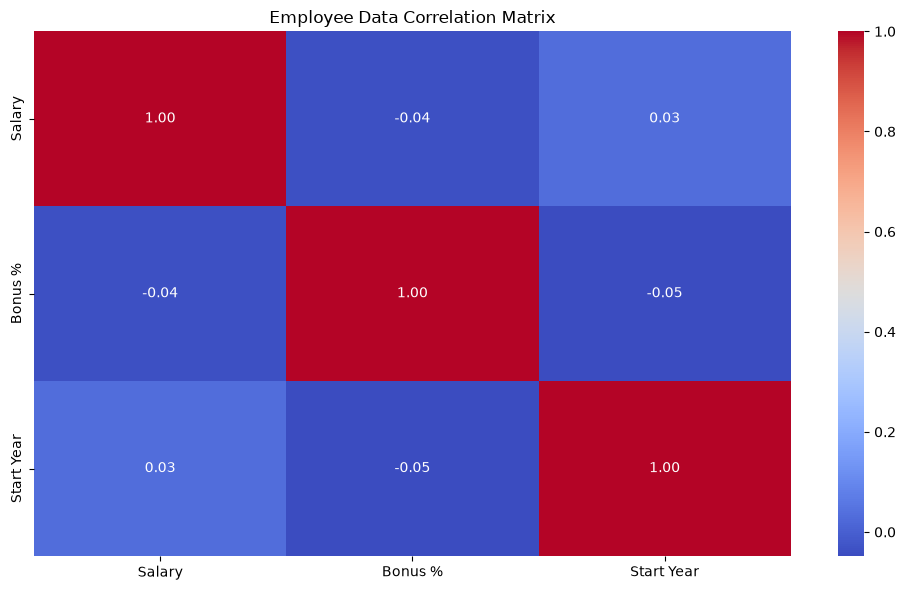

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(correlation,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Employee Data Correlation Matrix")
plt.tight_layout()
plt.show()

# 10=width,6=height correlation=this is correlation table ...heatmap use table to show through visually 
annot=True...each inside box show their numerical values .....cmap="coolwarm"  ..mean different values represent different colors .......fmt=".2f"   number show in 2 decimal places like 0.7883=0.78  

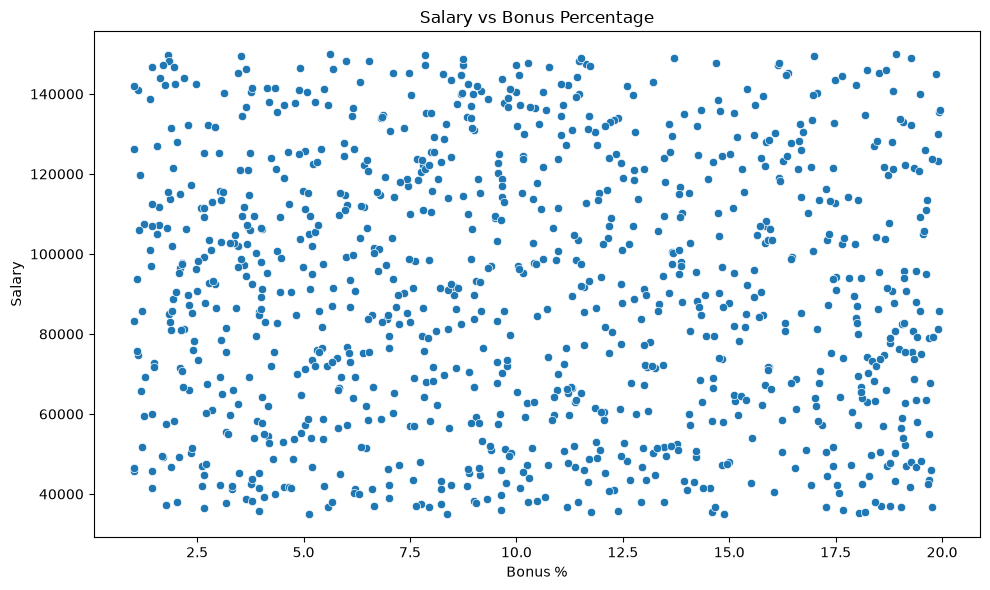

In [16]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x="Bonus %",
    y="Salary"
)
plt.title("Salary vs Bonus Percentage")
plt.xlabel("Bonus %")
plt.ylabel("Salary")
plt.tight_layout()
plt.show()

data=df...this is employees dataframe use  This scatter plot shows the relationship between Bonus Percentage and Salary for employees. Each dot represents one employee.

In [1]:
import pandas as pd

df = pd.read_csv("data/processed/cleaned_employess.csv")

print(df.groupby("Team")["Salary"].agg(
    ["count", "mean", "median", "min", "max"]
))

print("\nSalary by Senior Management:")
print(df.groupby("Senior Management")["Salary"].agg(
    ["count", "mean", "median"]
))

print("\nSalary by Gender:")
print(df.groupby("Gender")["Salary"].agg(
    ["count", "mean", "median"]
))

print("\nBonus-Salary Correlation:")
print(df[["Bonus %", "Salary"]].corr())

                      count          mean   median      min       max
Team                                                                 
Business Development    101  91866.316832  93997.0  36844.0  147417.0
Client Services         149  88957.073826  87103.0  35095.0  148291.0
Distribution             90  88500.466667  86842.0  35575.0  149105.0
Engineering              92  94269.195652  95273.0  36946.0  147362.0
Finance                 102  92219.480392  88873.5  35381.0  149908.0
Human Resources          91  90944.527473  93022.0  35203.0  149903.0
Legal                    88  89303.613636  87994.5  35061.0  148985.0
Marketing                98  90435.591837  85381.5  36643.0  149456.0
Product                  95  88665.505263  88657.0  35013.0  149684.0
Sales                    94  92173.436170  91238.5  35802.0  149654.0

Salary by Senior Management:
                   count          mean   median
Senior Management                              
False                465  89638.26

In [2]:
import os
print(os.getcwd)

<built-in function getcwd>
